In [2]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers

In [3]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [4]:
def pathGenerator(v, segments, g, eps = 0.001, maxSteps = 16, maxR = 10):
    x0 = v
    path = []
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return path, g(x0)
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
    return [], 0

In [5]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]

#v = np.array([0, 0])
def boundary(v):
    return v[1] * v[1] - v[0] * v[0]

In [6]:
target = []
width = range(1, 100)
height = range(1, 100)
for i in width:
    for j in height:
        target.append(np.array([i/50 - 1, j/50 - 1]))

print(len(target))

9801


In [7]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


In [8]:
paths1 = np.zeros((len(paths), maxPath, 2))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print(paths1.shape)

(8132, 16, 2)


In [9]:
paths1 = paths1.reshape(-1, 16, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [10]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(3)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [11]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(len(path[0]) - 1): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:3] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [12]:
class NNsolver(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver([32, 64, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=5e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [13]:
training = NNsolver(paths1, boundary1)
training.train_epoch(30, 256)

Metal device set to: Apple M1


2024-04-15 20:14:39.746729: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-04-15 20:14:39.746884: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


epoch: 0 loss: 0.6536413
epoch: 1 loss: 0.52722853
epoch: 2 loss: 0.3939497
epoch: 3 loss: 0.2504279
epoch: 4 loss: 0.1595947
epoch: 5 loss: 0.122750446
epoch: 6 loss: 0.10858489
epoch: 7 loss: 0.10296774
epoch: 8 loss: 0.10069564
epoch: 9 loss: 0.09986292
epoch: 10 loss: 0.099607676
epoch: 11 loss: 0.09818896
epoch: 12 loss: 0.09677563
epoch: 13 loss: 0.09599872
epoch: 14 loss: 0.09570326
epoch: 15 loss: 0.09516695
epoch: 16 loss: 0.094338775
epoch: 17 loss: 0.09346412
epoch: 18 loss: 0.092857584
epoch: 19 loss: 0.09254721
epoch: 20 loss: 0.09236455
epoch: 21 loss: 0.09186497
epoch: 22 loss: 0.09115112
epoch: 23 loss: 0.09054884
epoch: 24 loss: 0.09024432
epoch: 25 loss: 0.0901441
epoch: 26 loss: 0.090030566
epoch: 27 loss: 0.08959305
epoch: 28 loss: 0.08894092
epoch: 29 loss: 0.088498354


In [14]:
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        Z.append(training.model.model(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)



In [15]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

(101, 101)


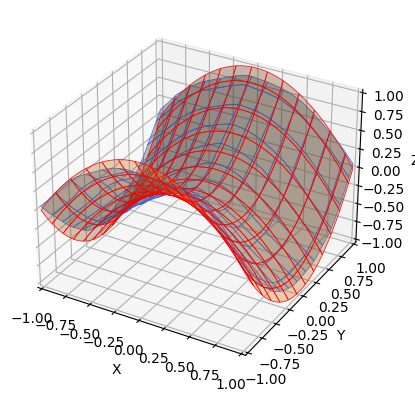

In [16]:
Z1 = Y*Y - X*X
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()

(101, 101)


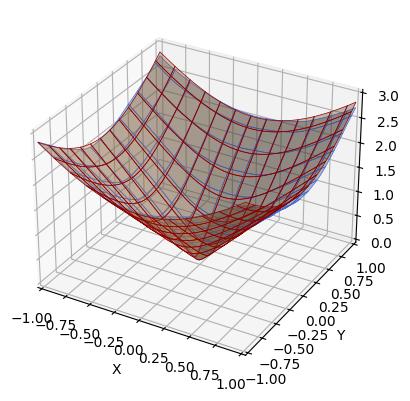

In [17]:
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:3].reshape(-1, 2), axis = 1).reshape(101, 101)
Z1 = 2 * np.sqrt(X*X + Y*Y)
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='darkred', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 3),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()